In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

from pixell import enmap, enplot, reproject
import glob
import matplotlib.pyplot as plt
import emcee, corner
from astropy.io import fits
import sys
from astropy import units as u, constants as const
sys.path.insert(0, '../src')
#sys.path.insert(0, "/home/gill/apps/szpack/python")
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
import yaml
import itertools
from pixell import enmap

import bandpass as bp
import covariance as cov
import model
import utils as ut

import SZpack as SZ

from astropy.coordinates import SkyCoord
import astropy.units as u

from pixell import colorize
from scipy.ndimage import gaussian_filter

In [ ]:
# from astropy.wcs import WCS
# from matplotlib.colors import LogNorm
# from pixell import enmap
# from astropy.visualization import (ZScaleInterval,
#                                     PercentileInterval,
#                                     MinMaxInterval,
#                                     ImageNormalize,
#                                     simple_norm)

# import matplotlib.pyplot as plt
# from astropy.io import fits
# import numpy as np

# # latex font sans-serif
# plt.rc('text', usetex=True)
# plt.rc('font', family='sans-serif', size=25)

# chandra_path = "/home/gill/research/ACT/paper/x_ray_radio/broad_flux.img.gz"
# chandra = fits.getdata(chandra_path)

# lofar_full = enmap.read_map("/home/gill/research/ACT/paper/x_ray_radio/uv_subtracted.fits")

# convergence = enmap.read_map("/home/gill/research/ACT/paper/x_ray_radio/A401_M_ap_SNR_b100_Rs7000.fits")
# convergence_wcs = convergence.wcs
# # smooth convergence map
# convergence = gaussian_filter(convergence, sigma=1)

# # Handle different possible shapes of LOFAR data
# if lofar_full.ndim == 4:
#     lofar = lofar_full[0, 0, :, :]
# elif lofar_full.ndim == 3:
#     lofar = lofar_full[0, :, :]
# elif lofar_full.ndim == 2:
#     lofar = lofar_full
# else:
#     raise ValueError(f"Unexpected LOFAR data shape: {lofar_full.shape}")

# # Get the WCS from the LOFAR map
# lofar_wcs = lofar.wcs

# # Calculate sigma for LOFAR contours
# lofar_sigma = np.std(lofar[np.isfinite(lofar)])
# lofar_contour_levels = np.array([2, 3, 4, 5, 6, 7, 8]) * lofar_sigma

# # Calculate sigma for convergence contours
# convergence_sigma = np.std(convergence)
# convergence_contour_levels = np.array([1.25, 1.5, 2, 3, 4, 5, 6]) * convergence_sigma

# # smooth the chandra image with a Gaussian kernel
# chandra = gaussian_filter(chandra, sigma=1)

# # Load the WCS information from the FITS header
# header = fits.getheader(chandra_path)
# wcs = WCS(header)

# # Handle zero/negative values for log normalization
# # Add small positive value to avoid log(0) issues
# norm = LogNorm()
# norm = ImageNormalize(chandra, interval=ZScaleInterval())
# norm = simple_norm(chandra, 'sqrt', percent=99.5)

# fig = plt.figure(figsize=(12, 7))
# ax = fig.add_subplot(111, projection=wcs)

# # Plot the image
# im = ax.imshow(chandra, cmap='turbo', origin='lower', norm=norm)

# # ax in degrees
# ax.coords[0].set_major_formatter('d.dd')
# ax.coords[1].set_major_formatter('d.dd')

# # model f90
# f90_model = enmap.read_map("/home/gill/research/ACT/paper/models/indiv/aug24_tSZ_only/total_model_all_three_systems_small_map/models/bridge_indv_150_pa5_model_uK.fits")

# # Get the WCS from the f90_model
# f90_wcs = f90_model.wcs

# sigma = np.std(f90_model)
# contour_levels = np.array([-11,-10, -8, -7, -5, -3, -2.]) * sigma
# #contour_levels = np.array([-400, -380, -370, -360, -350, -320, -300, -200, -100, -50])
# ax.contour(f90_model, levels=contour_levels, colors='white', linewidths=1.5, 
#            linestyles='solid',
#            alpha=1, transform=ax.get_transform(f90_wcs))

# # Add LOFAR contours
# ax.contour(lofar, levels=lofar_contour_levels, colors='darkgreen', linewidths=1.25, 
#            linestyles='solid', alpha=0.7, transform=ax.get_transform(lofar_wcs))

# # Add convergence contours
# ax.contour(convergence, levels=convergence_contour_levels, colors='orange', linewidths=1.5, 
#            linestyles='solid', alpha=1, transform=ax.get_transform(convergence_wcs))

# # Set coordinate labels
# ax.set_xlabel('Right Ascension')
# ax.set_ylabel('Declination')

# cbar = plt.colorbar(im, ax=ax, label='X-ray flux (photons/s/cm²)', orientation='vertical')
# cbar.ax.tick_params(labelsize=13)
# plt.tick_params(labelsize=20)
# plt.tight_layout()
# # plt.savefig('../plots/chandra_sz_v2.pdf', dpi=600, bbox_inches='tight')
# plt.show()

# # plot the image with contours again with a zoom in from Abell 399 at the bottom

# # Define zoom region around Abell 399 (bottom part of the image)
# # Assuming Abell 399 is in the lower portion, adjust these coordinates as needed
# zoom_xlim = [0, 1600]  # pixel coordinates for zoom
# zoom_ylim = [70, 1700]   # pixel coordinates for zoom

# fig = plt.figure(figsize=(12, 7))
# ax = fig.add_subplot(111, projection=wcs)

# # Plot the image with zoom
# im = ax.imshow(chandra, cmap='turbo', origin='lower', norm=norm)

# # Set the zoom limits
# ax.set_xlim(zoom_xlim)
# ax.set_ylim(zoom_ylim)

# # Add contours from the model
# ax.contour(f90_model, levels=contour_levels, colors='white', linewidths=1.5, 
#            linestyles='solid', alpha=1, transform=ax.get_transform(f90_wcs))

# # Add LOFAR contours
# ax.contour(lofar, levels=lofar_contour_levels, colors='green', linewidths=1.5, 
#            linestyles='solid', alpha=1, transform=ax.get_transform(lofar_wcs))

# # Add convergence contours
# ax.contour(convergence, levels=convergence_contour_levels, colors='orange', linewidths=1.5, 
#            linestyles='solid', alpha=1, transform=ax.get_transform(convergence_wcs))

# # Set coordinate labels
# ax.set_xlabel('Right Ascension')
# ax.set_ylabel('Declination')

# # Format coordinates
# ax.coords[0].set_major_formatter('d.dd')
# ax.coords[1].set_major_formatter('d.dd')

# cbar = plt.colorbar(im, ax=ax, label='X-ray flux (photons/s/cm²)', orientation='vertical')
# cbar.ax.tick_params(labelsize=13)
# plt.tick_params(labelsize=20)
# # plt.title('Zoomed view - Abell 399 region', fontsize=20)
# plt.tight_layout()
# #plt.savefig('../plots/chandra_sz_v3.pdf', dpi=600, bbox_inches='tight')
# plt.show()


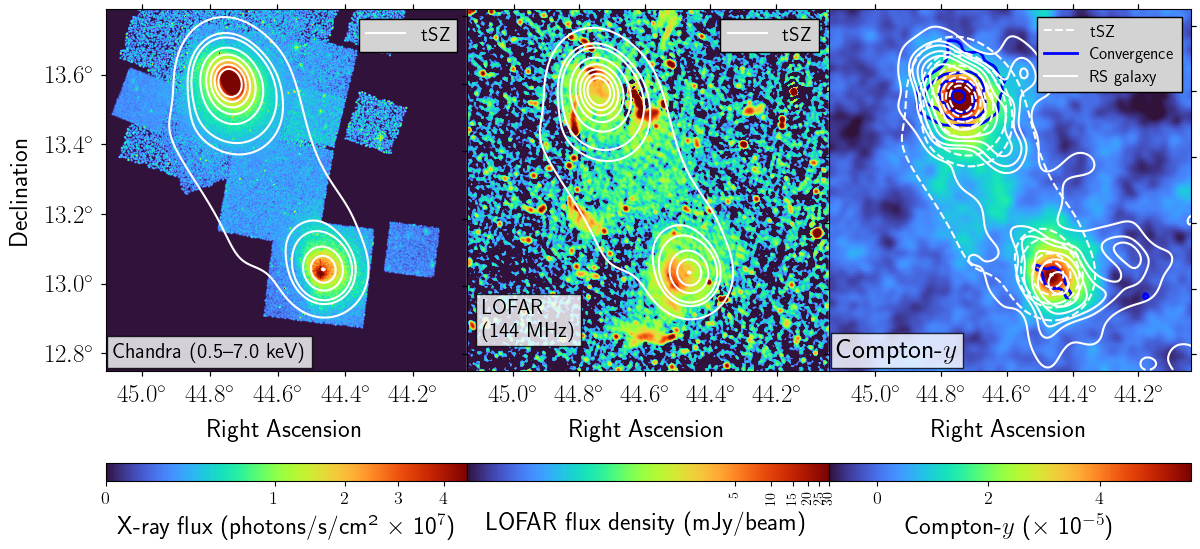

In [2]:
from astropy.wcs import WCS
from matplotlib.colors import LogNorm
from pixell import enmap

from matplotlib.colors import TwoSlopeNorm
from astropy.visualization import (ZScaleInterval,
                                    PercentileInterval,
                                    MinMaxInterval,
                                    ImageNormalize,
                                    simple_norm)

import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif', size=18)

cf = ut.get_config_file("../configs/case10_ajay.yaml")
region = ut.get_region(cf['region_center_ra'], 
                        cf['region_center_dec'], 
                        1.1)

# X-ray data
chandra_path = "/home/gill/research/ACT/paper/x_ray_radio/broad_flux.img.gz"
chandra = fits.getdata(chandra_path) * 10**7
chandra_hdr = fits.getheader(chandra_path)
chandra_wcs = WCS(chandra_hdr)

chandra_to_write = enmap.ndmap(chandra, chandra_wcs)

enmap.write_map("/home/gill/research/ACT/paper/x_ray_radio/chandra.fits", chandra_to_write)

chandra = enmap.read_map("/home/gill/research/ACT/paper/x_ray_radio/chandra.fits", box=region)
chandra_wcs = chandra.wcs
chandra = gaussian_filter(chandra, sigma=1.5)
chandra = enmap.ndmap(chandra, chandra_wcs)

# enmap.write_map("/home/gill/research/ACT/paper/x_ray_radio/chandra_small.fits", chandra)

# chandra = enmap.read_map("/home/gill/research/ACT/paper/x_ray_radio/chandra_small.fits")
chandra_std = np.std(chandra)
chandra_contour_levels = np.array([3, 4, 5, 6, 7, 8]) * chandra_std
chandra_wcs = chandra.wcs

# header = fits.getheader("/home/gill/research/ACT/paper/x_ray_radio/chandra.fits")
# wcs = WCS(header)

norm = ImageNormalize(chandra, interval=ZScaleInterval())
norm = simple_norm(chandra, 'sqrt', percent=99.5)
# norm = ImageNormalize(chandra, stretch=AsinhStretch(a=0.02))

# Add best_fit_tSZ contours
# best_fit_tSZ = enmap.read_map("/home/gill/research/ACT/paper/x_ray_radio/bridge_indv_98_pa5_model_uK.fits", box=region)
best_fit_tSZ = enmap.read_map("/home/gill/research/ACT/paper/models/indiv/sep14/small_map/SZ/models/bridge_indv_98_pa5_model_uK.fits", box=region)
best_fit_sigma = np.std(best_fit_tSZ)
best_fit_contour_levels = np.array([-7, -6, -5, -4, -3, -2, -1.7, -1]) * best_fit_sigma

fig = plt.figure(figsize=(14, 8))
# Plot 1: Chandra with tSZ contours

ax1 = fig.add_subplot(1, 3, 1, projection=chandra_wcs)
im1 = ax1.imshow(chandra, cmap='turbo', origin='lower', norm=norm)

ax1.set_xlim(0, 1900)
ax1.set_ylim(0, 1900)

ax1.contour(best_fit_tSZ, levels=best_fit_contour_levels, colors='white', linewidths=1.5, 
           linestyles='solid', alpha=1, transform=ax1.get_transform(best_fit_tSZ.wcs))
ax1.set_xlabel('Right Ascension')
ax1.set_ylabel('Declination')
ax1.coords[0].set_major_formatter('d.d')
ax1.coords[1].set_major_formatter('d.d')
ax1.invert_xaxis()

# hide x-axis tick labels
ax1.coords[0].set_ticklabel_visible(1)

ax1.text(0.02, 0.08, 'Chandra (0.5--7.0 keV)', transform=ax1.transAxes, fontsize=15,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

legend_elements1 = [Line2D([0], [0], color='white', lw=1.5, label='tSZ')]
ax1.legend(handles=legend_elements1, loc='upper right', fontsize=14, 
          frameon=True, fancybox=0, shadow=0, framealpha=1, facecolor='lightgray', edgecolor='black')
label1 = r'X-ray flux (photons/s/cm² $\times$ 10$^{7}$)'
cbar1 = plt.colorbar(im1, ax=ax1, label=label1, orientation='horizontal', shrink=1)
cbar1.ax.tick_params(labelsize=13, rotation=0)

# Plot 2: LOFAR with same limits
# LOFAR image with tSZ contours
scale_lofar = 1000  # convert Jy/beam to mJy/beam
lofar_full = enmap.read_map("/home/gill/research/ACT/paper/x_ray_radio/medium_resolution.fits", box=region) * scale_lofar

# Handle different possible shapes of LOFAR data
if lofar_full.ndim == 4:
    lofar = lofar_full[0, 0, :, :]
elif lofar_full.ndim == 3:
    lofar = lofar_full[0, :, :]
elif lofar_full.ndim == 2:
    lofar = lofar_full
else:
    raise ValueError(f"Unexpected LOFAR data shape: {lofar_full.shape}")

lofar_wcs = lofar.wcs
lofar = gaussian_filter(lofar, sigma=1.5)
lofar = enmap.ndmap(lofar, lofar_wcs)

# Get the WCS from the LOFAR map
lofar_wcs = lofar.wcs

# Calculate sigma for LOFAR contours
lofar_sigma = np.std(lofar[np.isfinite(lofar)])
# lofar_contour_levels = np.array([2, 3, 5, 7, 10]) * lofar_sigma
# Use sqrt stretch but enforce the same vmin/vmax used before
norm_lofar = simple_norm(lofar, 'log', vmin=scale_lofar * 5e-05, vmax=scale_lofar * 3e-02)
# norm_lofar = simple_norm(lofar, 'sqrt', percent=99.9)

ax2 = fig.add_subplot(1, 3, 2, projection=lofar_wcs)
im2 = ax2.imshow(lofar, cmap='turbo', origin='lower', norm=norm_lofar)
ax2.contour(best_fit_tSZ, levels=best_fit_contour_levels, colors='white', linewidths=1.5, 
           linestyles='solid', alpha=1, transform=ax2.get_transform(best_fit_tSZ.wcs))
ax2.set_xlabel('Right Ascension')
ax2.set_ylabel('Declination')
ax2.coords[0].set_major_formatter('d.d')
ax2.coords[1].set_major_formatter('d.d')

#ax2.set_xlim(0, 600)
ax2.set_ylim(0, 1285)

ax2.invert_xaxis()

ax2.text(0.04, 0.2, 'LOFAR \n(144 MHz)', transform=ax2.transAxes, fontsize=15,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

# hide x-axis tick labels
ax2.coords[0].set_ticklabel_visible(1)

legend_elements2 = [Line2D([0], [0], color='white', lw=1.5, label='tSZ')]
ax2.legend(handles=legend_elements2, loc='upper right', fontsize=14, 
          frameon=True, fancybox=0, shadow=0, framealpha=1, facecolor='lightgray', edgecolor='black')
cbar2 = plt.colorbar(im2, ax=ax2, label='LOFAR flux density (mJy/beam)', orientation='horizontal', shrink=1)
cbar2.ax.tick_params(labelsize=10, rotation=90)

# remove ax2 ylabels and yticks
ax2.coords[1].set_ticklabel_visible(0)

# Plot 3: Compton-y with same limits
norm_const = -3.526666833214854e-07
compton_y = enmap.read_map("/home/gill/research/ACT/paper/models/ymaps/regular.fits", box=region) * norm_const * 10**5
compton_y_std = np.std(compton_y[np.isfinite(compton_y)])
compton_y_contour_levels = np.array([2, 2.5, 3, 4, 5, 6]) * compton_y_std

convergence = enmap.read_map("/home/gill/research/ACT/paper/x_ray_radio/A401_M_ap_b100_Rs7000_signal.fits", box=region)
RS = enmap.read_map("/home/gill/research/ACT/paper/x_ray_radio/A401_density_b100_bw200kpc.fits", box=region)

compton_y_wcs = compton_y.wcs
compton_y = gaussian_filter(compton_y, sigma=1.5)
compton_y = enmap.ndmap(compton_y, compton_y_wcs)

# Calculate sigma and contour levels for convergence and RS maps
convergence_sigma = np.std(convergence)
convergence_contour_levels = np.array([2, 3, 4, 5]) * convergence_sigma

RS_sigma = np.std(RS)
RS_contour_levels = np.arange(0.024, 0.12, 0.024)
RS_contour_levels = np.array([1, 1.7, 2, 2.5, 3, 4]) * RS_sigma

ax3 = fig.add_subplot(1, 3, 3, projection=compton_y.wcs)
norm_y = simple_norm(compton_y, 'linear', percent=99)
im3 = ax3.imshow(compton_y, cmap='turbo', origin='lower', norm=norm_y)

ax3.contour(convergence, levels=convergence_contour_levels, colors='blue', 
           linewidths=2, linestyles='solid', alpha=1, 
           transform=ax3.get_transform(convergence.wcs))
ax3.contour(RS, levels=RS_contour_levels, colors='white', 
           linewidths=1.5, linestyles='solid', alpha=1, 
           transform=ax3.get_transform(RS.wcs))
ax3.contour(best_fit_tSZ, levels=best_fit_contour_levels, colors='white', 
           linewidths=1.5, linestyles='dashed', alpha=1, 
           transform=ax3.get_transform(best_fit_tSZ.wcs))
# ax3.contour(compton_y, levels=compton_y_contour_levels, colors='pink', 
#            linewidths=1.5, linestyles=':', alpha=1, 
#            transform=ax3.get_transform(compton_y.wcs))

ax3.set_xlabel('Right Ascension')
ax3.set_ylabel('Declination')
ax3.coords[0].set_major_formatter('d.d')
ax3.coords[1].set_major_formatter('d.d')

ax3.set_xlim(0, 132)
ax3.set_ylim(0, 132)
ax3.invert_xaxis()

ax3.text(0.02, 0.09, 'Compton-$y$', transform=ax3.transAxes, fontsize=20,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

legend_elements3 = [
    Line2D([0], [0], color='white', lw=1.5, label='tSZ', linestyle='dashed'),
    Line2D([0], [0], color='blue', lw=2, label='Convergence'),
    # Line2D([0], [0], color='pink', lw=1.5, label='Compton-$y$'),
    Line2D([0], [0], color='white', lw=1.5, label='RS galaxy')
]
ax3.legend(handles=legend_elements3, loc='upper right', fontsize=12, 
          frameon=True, fancybox=False, shadow=False, framealpha=1, 
          facecolor='lightgray', edgecolor='black')

ax3.coords[1].set_ticklabel_visible(0)

cbar3 = plt.colorbar(im3, ax=ax3, label=r'Compton-$y$ ($\times$ 10$^{-5}$)', orientation='horizontal', shrink=1)
cbar3.ax.tick_params(labelsize=13)

# Adjust layout and show
#plt.tight_layout()
# reduce white space
plt.subplots_adjust(hspace=0., wspace=0)
plt.savefig("../plots/multi_wave_figure_sep14.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
RS_sigma = np.std(RS)
RS_contour_levels = np.arange(0.024, 0.12, 0.024)
print(RS_contour_levels/RS_sigma)

In [ ]:
RS_contour_levels

In [ ]:
from astropy.wcs import WCS
from matplotlib.colors import LogNorm
from pixell import enmap
from astropy.visualization import (ImageNormalize, PercentileInterval,
                                   AsinhStretch, LogStretch)

from matplotlib.colors import TwoSlopeNorm
from astropy.visualization import (ZScaleInterval,
                                    PercentileInterval,
                                    MinMaxInterval,
                                    ImageNormalize,
                                    simple_norm)

import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D

# latex font sans-serif
plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif', size=20)

cf = ut.get_config_file("../configs/case10_ajay.yaml")
region = ut.get_region(cf['region_center_ra'], 
                        cf['region_center_dec'], 
                        1.75)

chandra_path = "/home/gill/research/ACT/paper/x_ray_radio/broad_flux.img.gz"
#chandra = fits.getdata(chandra_path) * 10**7
chandra = enmap.read_map(chandra_path) * 1e7
chandra = gaussian_filter(chandra, sigma=1)

header = fits.getheader(chandra_path)
wcs = WCS(header)

# Handle zero/negative values for log normalization
# Add small positive value to avoid log(0) issues
# norm = ImageNormalize(chandra, interval=ZScaleInterval())
norm = simple_norm(chandra, 'sqrt', percent=99.5)
#norm = ImageNormalize(chandra, stretch=AsinhStretch(a=0.02))

# model f90
f90_model = enmap.read_map("/home/gill/research/ACT/paper/models/indiv/aug24_tSZ_only/total_model_all_three_systems_small_map/models/bridge_indv_150_pa5_model_uK.fits", box=region)

# Get the WCS from the f90_model
f90_wcs = f90_model.wcs
sigma = np.std(f90_model)
contour_levels = np.array([-10, -8, -6, -4, -3, -2]) * sigma

# figure 1
# fig = plt.figure(figsize=(12, 7))
# ax = fig.add_subplot(111, projection=wcs)

# # Plot the image
# im = ax.imshow(chandra, cmap='turbo', origin='lower', norm=norm)

# # ax in degrees
# ax.coords[0].set_major_formatter('d.dd')
# ax.coords[1].set_major_formatter('d.dd')



# ax.contour(f90_model, levels=contour_levels, colors='white', linewidths=1.5, 
#            linestyles='solid',
#            alpha=1, transform=ax.get_transform(f90_wcs))

# # Set coordinate labels
# ax.set_xlabel('Right Ascension')
# ax.set_ylabel('Declination')

# cbar = plt.colorbar(im, ax=ax, label='X-ray flux (photons/s/cm²)', orientation='vertical')
# cbar.ax.tick_params(labelsize=13)
# plt.tick_params(labelsize=20)
# plt.tight_layout()
# # plt.savefig('../plots/chandra_sz_v2.pdf', dpi=600, bbox_inches='tight')
# plt.show()

# fig 2
zoom_xlim = [0, 1600]  # pixel coordinates for zoom
zoom_ylim = [0, 1700]   # pixel coordinates for zoom

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection=wcs)

# Plot the image with zoom
im = ax.imshow(chandra, cmap='turbo', origin='lower', norm=norm)

# Set the zoom limits
ax.set_xlim(zoom_xlim)
ax.set_ylim(zoom_ylim)

# Add contours from the model
ax.contour(f90_model, levels=contour_levels, colors='white', linewidths=1.5, 
           linestyles='solid', alpha=1, transform=ax.get_transform(f90_wcs))

# Set coordinate labels
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')

# Format coordinates
ax.coords[0].set_major_formatter('d.dd')
ax.coords[1].set_major_formatter('d.dd')

# place text at the bottom left with a legned saying white is tSZ contours
# Create a legend for the contours
legend_elements = [Line2D([0], [0], color='white', lw=1.5, label='tSZ contours')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12, 
          frameon=True, fancybox=0, shadow=0, framealpha=1, facecolor='lightgrey', edgecolor='black')

label=r'X-ray flux (photons/s/cm²) $\times$ 10$^{7}$'
cbar = plt.colorbar(im, ax=ax, label=label, orientation='horizontal', shrink=0.4)
cbar.ax.tick_params(labelsize=13)
plt.tick_params(labelsize=18)
plt.tight_layout()
#plt.savefig('../plots/chandra_sz_v3.pdf', dpi=600, bbox_inches='tight')

plt.show()

# LOFAR image with tSZ contours
lofar_full = enmap.read_map("/home/gill/research/ACT/paper/x_ray_radio/uv_subtracted.fits", box=region)

# Handle different possible shapes of LOFAR data
if lofar_full.ndim == 4:
    lofar = lofar_full[0, 0, :, :]
elif lofar_full.ndim == 3:
    lofar = lofar_full[0, :, :]
elif lofar_full.ndim == 2:
    lofar = lofar_full
else:
    raise ValueError(f"Unexpected LOFAR data shape: {lofar_full.shape}")

# Get the WCS from the LOFAR map
lofar_wcs = lofar.wcs

# Calculate sigma for LOFAR contours
lofar_sigma = np.std(lofar[np.isfinite(lofar)])
lofar_contour_levels = np.array([2.5, 3, 5, 7, 10]) * lofar_sigma

# Define zoom limits for LOFAR (adjust these as needed)
lofar_zoom_xlim = [450, 1000]  # pixel coordinates for zoom
lofar_zoom_ylim = [400, 1100]  # pixel coordinates for zoom

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection=lofar_wcs)

# Plot the LOFAR image
norm_lofar = simple_norm(lofar, 'linear', percent=99.9)
im = ax.imshow(lofar, cmap='magma', origin='lower', norm=norm_lofar)

# Set the zoom limits
ax.set_xlim(lofar_zoom_xlim)
ax.set_ylim(lofar_zoom_ylim)

# Add tSZ contours from the model
ax.contour(f90_model, levels=contour_levels, colors='white', linewidths=1.5, 
            linestyles='solid', alpha=1, transform=ax.get_transform(f90_wcs))

# Set coordinate labels
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')

# Format coordinates
ax.coords[0].set_major_formatter('d.dd')
ax.coords[1].set_major_formatter('d.dd')

# Create a legend for the contours
legend_elements = [Line2D([0], [0], color='white', lw=1.5, label='tSZ contours')]
ax.legend(handles=legend_elements, loc='lower left', fontsize=12, 
          frameon=True, fancybox=0, shadow=0, framealpha=1, facecolor='lightgray', edgecolor='black')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, label='LOFAR flux density (Jy/beam)', orientation='horizontal', shrink=0.3)
cbar.ax.tick_params(labelsize=13)
plt.tick_params(labelsize=18)
plt.tight_layout()
plt.show()

# Add best_fit_tSZ contours
best_fit_tSZ = enmap.read_map("/home/gill/research/ACT/paper/x_ray_radio/bridge_indv_98_pa5_model_uK.fits", box=region)

best_fit_sigma = np.std(best_fit_tSZ)
best_fit_contour_levels = np.array([-10, -8, -6, -4, -3, -2]) * best_fit_sigma

cf = ut.get_config_file("../configs/case10_ajay.yaml")
region = ut.get_region(cf['region_center_ra'], 
                        cf['region_center_dec'], 
                        1.75)

norm_const = -3.526666833214854e-07
compton_y = enmap.read_map("/home/gill/research/ACT/paper/models/ymaps/regular.fits", box=region) * norm_const * 10**5
convergence = enmap.read_map("/home/gill/research/ACT/paper/x_ray_radio/convergence_A401_M_ap_b100_Rs7000_signal.fits", box=region)
RS = enmap.read_map("/home/gill/research/ACT/paper/x_ray_radio/RS_A401_density_b100_bw200kpc.fits", box=region)

# Get the WCS from the compton_y map
compton_y_wcs = compton_y.wcs

# Calculate sigma and contour levels for convergence and RS maps
convergence_sigma = np.std(convergence)
convergence_contour_levels = np.array([2, 3, 4, 5, 6]) * convergence_sigma

RS_sigma = np.std(RS)
RS_contour_levels = np.array([2, 3, 4, 5, 6]) * RS_sigma

# Define zoom limits (adjust as needed)
y_zoom_xlim = [30, 180]
y_zoom_ylim = [40, 180]

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection=compton_y_wcs)

# Plot the Compton-y map
norm_y = simple_norm(compton_y, 'linear', percent=99.)
im = ax.imshow(compton_y, cmap='magma', origin='lower', norm=norm_y)

# Set zoom limits
ax.set_xlim(y_zoom_xlim)
ax.set_ylim(y_zoom_ylim)
ax.invert_xaxis()

ax.contour(convergence, levels=convergence_contour_levels, colors='red', 
           linewidths=1.5, linestyles='solid', alpha=1, 
           transform=ax.get_transform(convergence_wcs))

# Add RS contours
ax.contour(RS, levels=RS_contour_levels, colors='green', 
           linewidths=1.5, linestyles='solid', alpha=1, 
           transform=ax.get_transform(RS.wcs))

ax.contour(best_fit_tSZ, levels=best_fit_contour_levels, colors='white', 
           linewidths=1., linestyles='dashed', alpha=0.7, 
           transform=ax.get_transform(best_fit_tSZ.wcs))

# Set coordinate labels
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')

# Format coordinates
ax.coords[0].set_major_formatter('d.dd')
ax.coords[1].set_major_formatter('d.dd')

# Update the legend to include the best fit tSZ contours
legend_elements = [
    Line2D([0], [0], color='white', lw=1., label='Best fit tSZ contours', linestyle='dashed'),
    Line2D([0], [0], color='red', lw=1.5, label='Convergence contours'),
    Line2D([0], [0], color='green', lw=1.5, label='RS contours')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12, 
          frameon=True, fancybox=False, shadow=False, framealpha=1, 
          facecolor='lightgray', edgecolor='black')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, label=r'Compton-$y$ ($\times$ 10$^{-5}$)', orientation='horizontal', shrink=0.4)
cbar.ax.tick_params(labelsize=13)
plt.tick_params(labelsize=18)
plt.tight_layout()
plt.show()


In [ ]:
xmm = enmap.read_map("/home/gill/research/ACT/paper/x_ray_radio/counts_sec_conv_HGEOM_nps.fits")
lofar_full = enmap.read_map("/home/gill/research/ACT/paper/x_ray_radio/A399_A401_LOFAR_80_HGEOM_CONV99.FITS")
lofar_full = enmap.read_map("/home/gill/research/ACT/paper/x_ray_radio/uv_subtracted.fits")

# Handle different possible shapes of LOFAR data
if lofar_full.ndim == 4:
    lofar = lofar_full[0, 0, :, :]
elif lofar_full.ndim == 3:
    lofar = lofar_full[0, :, :]
elif lofar_full.ndim == 2:
    lofar = lofar_full
else:
    raise ValueError(f"Unexpected LOFAR data shape: {lofar_full.shape}")

# Get the WCS from the LOFAR map
lofar_wcs = lofar.wcs

# Calculate sigma for LOFAR contours
lofar_sigma = np.std(lofar[np.isfinite(lofar)])
lofar_contour_levels = np.array([2.5, 3, 5, 7, 10]) * lofar_sigma

# Plot the XMM map with WCS projection
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection=xmm.wcs)
norm = ImageNormalize(xmm, interval=ZScaleInterval())
# Alternatively, you can use simple_norm for a different normalization
norm = simple_norm(xmm, 'linear', percent=99)
im = ax.imshow(xmm, cmap='turbo', origin='lower', norm=norm)

# Add contours from f90_model
sigma = np.std(f90_model)
contour_levels = np.array([-10, -8, -5, -4, -3, -2]) * sigma
ax.contour(f90_model, levels=contour_levels, colors='red', linewidths=1.5, 
           linestyles='solid', alpha=0.7, transform=ax.get_transform(f90_wcs))

# Add LOFAR contours
ax.contour(lofar, levels=lofar_contour_levels, colors='white', linewidths=1.5,
           linestyles='solid', alpha=0.7, transform=ax.get_transform(lofar_wcs))

ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
plt.colorbar(im, ax=ax, label='XMM counts', orientation='vertical')
plt.title('XMM Map with SZ and LOFAR contours')
plt.tick_params(labelsize=20)
plt.tight_layout()
plt.show()

# Plot the LOFAR map with WCS projection
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection=lofar_wcs)
norm = simple_norm(lofar, 'linear', percent=99)
im = ax.imshow(lofar, cmap='turbo', origin='lower', norm=norm)

# Add contours from f90_model
ax.contour(f90_model, levels=contour_levels, colors='red', linewidths=1.5,
           linestyles='solid', alpha=0.7, transform=ax.get_transform(f90_wcs))

# Add LOFAR contours
ax.contour(lofar, levels=lofar_contour_levels, colors='white', linewidths=1.5,
           linestyles='solid', alpha=0.8)

ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
plt.colorbar(im, ax=ax, label='LOFAR intensity', orientation='vertical')
plt.title('LOFAR Map with SZ contours')
plt.tick_params(labelsize=20)
plt.tight_layout()
plt.show()

# Chandra map with contours
fig = plt.figure(figsize=(12, 7))
header = fits.getheader("/home/gill/Downloads/broad_flux.img_recent.gz")
wcs = WCS(header)
ax = fig.add_subplot(111, projection=wcs)
norm = ImageNormalize(chandra, interval=ZScaleInterval())
norm = simple_norm(chandra, 'sqrt', percent=99)
im = ax.imshow(chandra, cmap='turbo', origin='lower', norm=norm)    

# Set the limits to match the Chandra image dimensions
ax.set_xlim(0, chandra.shape[1])
ax.set_ylim(0, chandra.shape[0])

# Add contours from f90_model
sigma = np.std(f90_model)
contour_levels = np.array([-10, -8, -5, -4, -3, -2]) * sigma
ax.contour(f90_model, levels=contour_levels, colors='red', linewidths=1.5, 
           linestyles='solid', alpha=0.7, transform=ax.get_transform(f90_wcs))      
# Add LOFAR contours
ax.contour(lofar, levels=lofar_contour_levels, colors='white', linewidths=1.5,
           linestyles='solid', alpha=0.7, transform=ax.get_transform(lofar_wcs))    
# Set coordinate labels
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')    
# Format coordinates
ax.coords[0].set_major_formatter('d.dd')
ax.coords[1].set_major_formatter('d.dd')    
cbar = plt.colorbar(im, ax=ax, label='Chandra counts', orientation='vertical')
cbar.ax.tick_params(labelsize=13)
plt.tick_params(labelsize=20)
plt.tight_layout()
# plt.savefig('../plots/chandra_sz_lofar_contours.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
# plot lofar map with contours
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection=lofar_wcs)
norm = simple_norm(lofar, 'linear', percent=99)
im = ax.imshow(lofar, cmap='turbo', origin='lower', norm=norm)
# Add contours from f90_model
ax.contour(f90_model, levels=contour_levels, colors='red', linewidths=1.5,
           linestyles='solid', alpha=0.7, transform=ax.get_transform(f90_wcs))  
# Add LOFAR contours
ax.contour(lofar, levels=lofar_contour_levels, colors='white', linewidths=1.5,
           linestyles='solid', alpha=0.8)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
plt.colorbar(im, ax=ax, label='LOFAR intensity', orientation='vertical')
plt.title('LOFAR Map with SZ contours')
plt.tick_params(labelsize=20)
plt.tight_layout()
# plt.savefig('../plots/lofar_sz_contours.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
# plot the model on the image
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection=f90_wcs)
# Plot the image
im = ax.imshow(f90_model, cmap='viridis', origin='lower')
# plot contours from the model on the image in terms of sigma 

# Calculate standard deviation of the model
sigma = np.std(f90_model)
contour_levels = np.array([-10, -5, -4, -3, -2, -1]) * sigma
ax.contour(f90_model, levels=contour_levels, colors='red', linewidths=2, 
           alpha=1, transform=ax.get_transform(f90_wcs))

In [ ]:
import utils as ut

dire_base = os.getenv("DIRE_BASE")

array = "npipe"
frequency = 30
freq_str = ut.get_freq_str(frequency=frequency)
x_array, freq_array, del_freq = ut.get_freq_bandpass(array=array, freq_str=freq_str)
bandpass, bandpass_int = ut.get_bandpass(array=array, freq_str=freq_str)
# bandpass = bp.load_passband_transmission("passband_npipe_f030.npy", dire_base=dire_base)

#normalize the bandpass to the max value
#bandpass /= np.max(bandpass)
# bandpass_int = bp.integrate_passband(bandpass, freq_array)

params = SZ.parameters()
params.betao = 1.241e-3                # Peculiar velocity of observer with respect to CMB frame (betac = v/c)
params.betao = 0                       # Peculiar velocity of observer with respect to CMB frame (betac = v/c)
params.muo = 0.0                  # Cosine of line-of-sight to the observers velocity. Angle measured in the observer frame
params.betac = 0/3e5               # Peculiar velocity of cluster with respect to CMB frame (betao = v/c)
params.muc = 0.3                  # Cosine of cluster velocity to the line-of-sight in the CMB rest frame
params.Te = 8                  # Electron temperature in keV
params.Dtau = 0.01             # The optical depth (must be > 0)
params.check_values()       # A function to check that the values set are valid.
params.runmode = "full"      # We will discuss this setting more later in this document.
params.set_x_array(x_array[0], x_array[-1], len(x_array))

combo_tsz = SZ.compute_combo(params, DI=True)


numerator = np.trapz(y=bandpass * np.array(combo_tsz),
                     x=freq_array, dx=del_freq)

sz_signal = numerator / (bandpass_int) # SZ model

print("SZ signal:", sz_signal)

# plot the bandpass

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(freq_array, bandpass, label='Bandpass', color='blue')
ax.axhline(y=0, color='black', linestyle='--')
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Bandpass')
ax.set_title('Bandpass for {} at {} GHz'.format(array, frequency))
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
combo_tsz